In [1]:
# Import libraries
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.ndimage import center_of_mass
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Activation,
    Add,
    BatchNormalization,
    Concatenate,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
warnings.filterwarnings('ignore')

# Set random seed
SEED = 42
LOAD_PRETRAINED = False
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

TensorFlow version: 2.16.1
Keras version: 3.12.0


In [2]:
# Load dataset
data = np.load('dataset_dev_3000.npz')
X = data['X']
y = data['y']

In [3]:
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y[:, 0],  # Stratify on Target A (10 classes) - like test_clean.ipynb
)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

Training set: (2400, 32, 32)
Validation set: (600, 32, 32)


In [4]:
# Prepare data for multi-task training
X_train_mtl = X_train[..., None].astype('float32')
X_val_mtl = X_val[..., None].astype('float32')

# Normalize
mean = X_train_mtl.mean()
std = X_train_mtl.std() + 1e-6
X_train_mtl = (X_train_mtl - mean) / std
X_val_mtl = (X_val_mtl - mean) / std

# Extract targets
y_A_train, y_B_train, y_C_train = y_train[:, 0], y_train[:, 1], y_train[:, 2]
y_A_val, y_B_val, y_C_val = y_val[:, 0], y_val[:, 1], y_val[:, 2]

In [5]:
def build_mtl_model(input_shape=(32, 32, 1)):
    inputs = Input(shape=input_shape)

    # -------- Shared stem (VERY shallow) --------
    x = Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = MaxPooling2D(2)(x)

    x = Conv2D(64, 3, padding="same", activation="relu")(x)
    x = MaxPooling2D(2)(x)

    # -------- Target A head (strong) --------
    a = Conv2D(64, 3, padding="same", activation="relu")(x)
    a = MaxPooling2D(2)(a)
    a = Flatten()(a)
    a = Dense(128, activation="relu")(a)
    a = Dropout(0.6)(a)
    output_A = Dense(10, activation="softmax", name="output_A")(a)

    # -------- Target B head (wider, less deep) --------
    b = GlobalAveragePooling2D(name="B_gap")(x)
    b = Dense(64, activation="relu", name="B_dense")(b)
    b = Dropout(0.6, name="B_dropout")(b)
    output_B = Dense(32, activation="softmax", name="output_B")(b)

    
    # -------- Target C head (light regression) --------
    c = GlobalAveragePooling2D()(x)
    c = Dense(64, activation="relu")(c)
    output_C = Dense(1, activation="linear", name="output_C")(c)

    model = Model(
        inputs=inputs,
        outputs={
            "output_A": output_A,
            "output_B": output_B,
            "output_C": output_C,
        },
    )

    model.compile(
        optimizer=Adam(learning_rate=3e-4),
        loss={
            "output_A": "sparse_categorical_crossentropy",
            "output_B": "sparse_categorical_crossentropy",
            "output_C": "mse",
        },
        loss_weights={
            "output_A": 1.2,  # protect A
            "output_B": 0.7,
            "output_C": 0.4,  # prevent dominance
        },
        metrics={
            "output_A": "accuracy",
            "output_B": "accuracy",
            "output_C": "mae",
        },
    )

    return model


# Build the model only if not loading pretrained
if not LOAD_PRETRAINED:
    print("Building model from scratch...")
    hypothesis_model = build_mtl_model()
    hypothesis_model.summary()
else:
    print("Model already loaded from file. Skipping build step.")

Building model from scratch...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 16,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 16, 16,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 8, 64)  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 64)  │     36,928 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 4, 4, 64)  │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1024)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ B_gap               │ (None, 64)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    131,200 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ B_dense (Dense)     │ (None, 64)        │      4,160 │ B_gap[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ B_dropout (Dropout) │ (None, 64)        │          0 │ B_dense[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_A (Dense)    │ (None, 10)        │      1,290 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_B (Dense)    │ (None, 32)        │      2,080 │ B_dropout[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_C (Dense)    │ (None, 1)         │         65 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 198,699 (776.17 KB)

 Trainable params: 198,699 (776.17 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
def train():

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=6, min_lr=1e-5),
    ]

    classes = np.unique(y_B_train)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y_B_train,
    )
    class_weight_B = dict(zip(classes, weights))

    sample_weight = {
        "output_A": np.ones(len(y_A_train), dtype=np.float32),
        "output_B": np.array(
            [class_weight_B[y] for y in y_B_train],
            dtype=np.float32,
        ),
        "output_C": np.ones(len(y_C_train), dtype=np.float32),
    }

    history = hypothesis_model.fit(
        X_train_mtl,
        {
            "output_A": y_A_train,
            "output_B": y_B_train,
            "output_C": y_C_train,
        },
        sample_weight=sample_weight,
        validation_data=(
            X_val_mtl,
            {
                "output_A": y_A_val,
                "output_B": y_B_val,
                "output_C": y_C_val,
            },
        ),
        epochs=80,
        batch_size=64,
        callbacks=callbacks,
        verbose=2,
    )

    return history

history_mtl = train()


Epoch 1/80
38/38 - 3s - 77ms/step - loss: 5.2570 - output_A_accuracy: 0.1046 - output_A_loss: 2.3070 - output_B_accuracy: 0.0267 - output_B_loss: 3.4793 - output_C_loss: 0.1302 - output_C_mae: 0.2989 - val_loss: 5.1810 - val_output_A_accuracy: 0.1683 - val_output_A_loss: 2.2675 - val_output_B_accuracy: 0.0300 - val_output_B_loss: 3.4703 - val_output_C_loss: 0.0787 - val_output_C_mae: 0.2403 - learning_rate: 3.0000e-04
Epoch 2/80
38/38 - 1s - 17ms/step - loss: 5.1759 - output_A_accuracy: 0.1475 - output_A_loss: 2.2645 - output_B_accuracy: 0.0342 - output_B_loss: 3.4693 - output_C_loss: 0.0775 - output_C_mae: 0.2394 - val_loss: 5.1252 - val_output_A_accuracy: 0.2167 - val_output_A_loss: 2.2248 - val_output_B_accuracy: 0.0233 - val_output_B_loss: 3.4701 - val_output_C_loss: 0.0703 - val_output_C_mae: 0.2266 - learning_rate: 3.0000e-04
Epoch 3/80
38/38 - 1s - 18ms/step - loss: 5.1211 - output_A_accuracy: 0.1796 - output_A_loss: 2.2207 - output_B_accuracy: 0.0362 - output_B_loss: 3.4710 - o

In [7]:
# Evaluate hypothesis-driven MTL model
print("\n" + "=" * 60)
print("HYPOTHESIS-DRIVEN MTL MODEL EVALUATION")
print("=" * 60)

# Get predictions (DICT)
preds = hypothesis_model.predict(X_val_mtl, verbose=0)

y_pred_A = preds["output_A"]
y_pred_B = preds["output_B"]
y_pred_C = preds["output_C"]

# Convert predictions to class labels
y_pred_A_labels = np.argmax(y_pred_A, axis=1)
y_pred_B_labels = np.argmax(y_pred_B, axis=1)

# Calculate metrics
acc_A = np.mean(y_pred_A_labels == y_A_val)
acc_B = np.mean(y_pred_B_labels == y_B_val)
mae_C = np.mean(np.abs(y_pred_C.squeeze() - y_C_val))

print("\nTarget A (Global Shape/Geometry):")
print(f"  Accuracy: {acc_A*100:.2f}%")
print(f"  Random baseline: {1/10*100:.2f}%")

print("\nTarget B (Orientation/Fine Structure):")
print(f"  Accuracy: {acc_B*100:.2f}%")
print(f"  Random baseline: {1/32*100:.2f}%")

print("\nTarget C (Intensity/Amplitude):")
print(f"  MAE: {mae_C:.4f}")
print(f"  Range: [{y_C_val.min():.4f}, {y_C_val.max():.4f}]")



HYPOTHESIS-DRIVEN MTL MODEL EVALUATION

Target A (Global Shape/Geometry):
  Accuracy: 38.33%
  Random baseline: 10.00%

Target B (Orientation/Fine Structure):
  Accuracy: 2.50%
  Random baseline: 3.12%

Target C (Intensity/Amplitude):
  MAE: 0.1354
  Range: [0.0035, 0.9984]


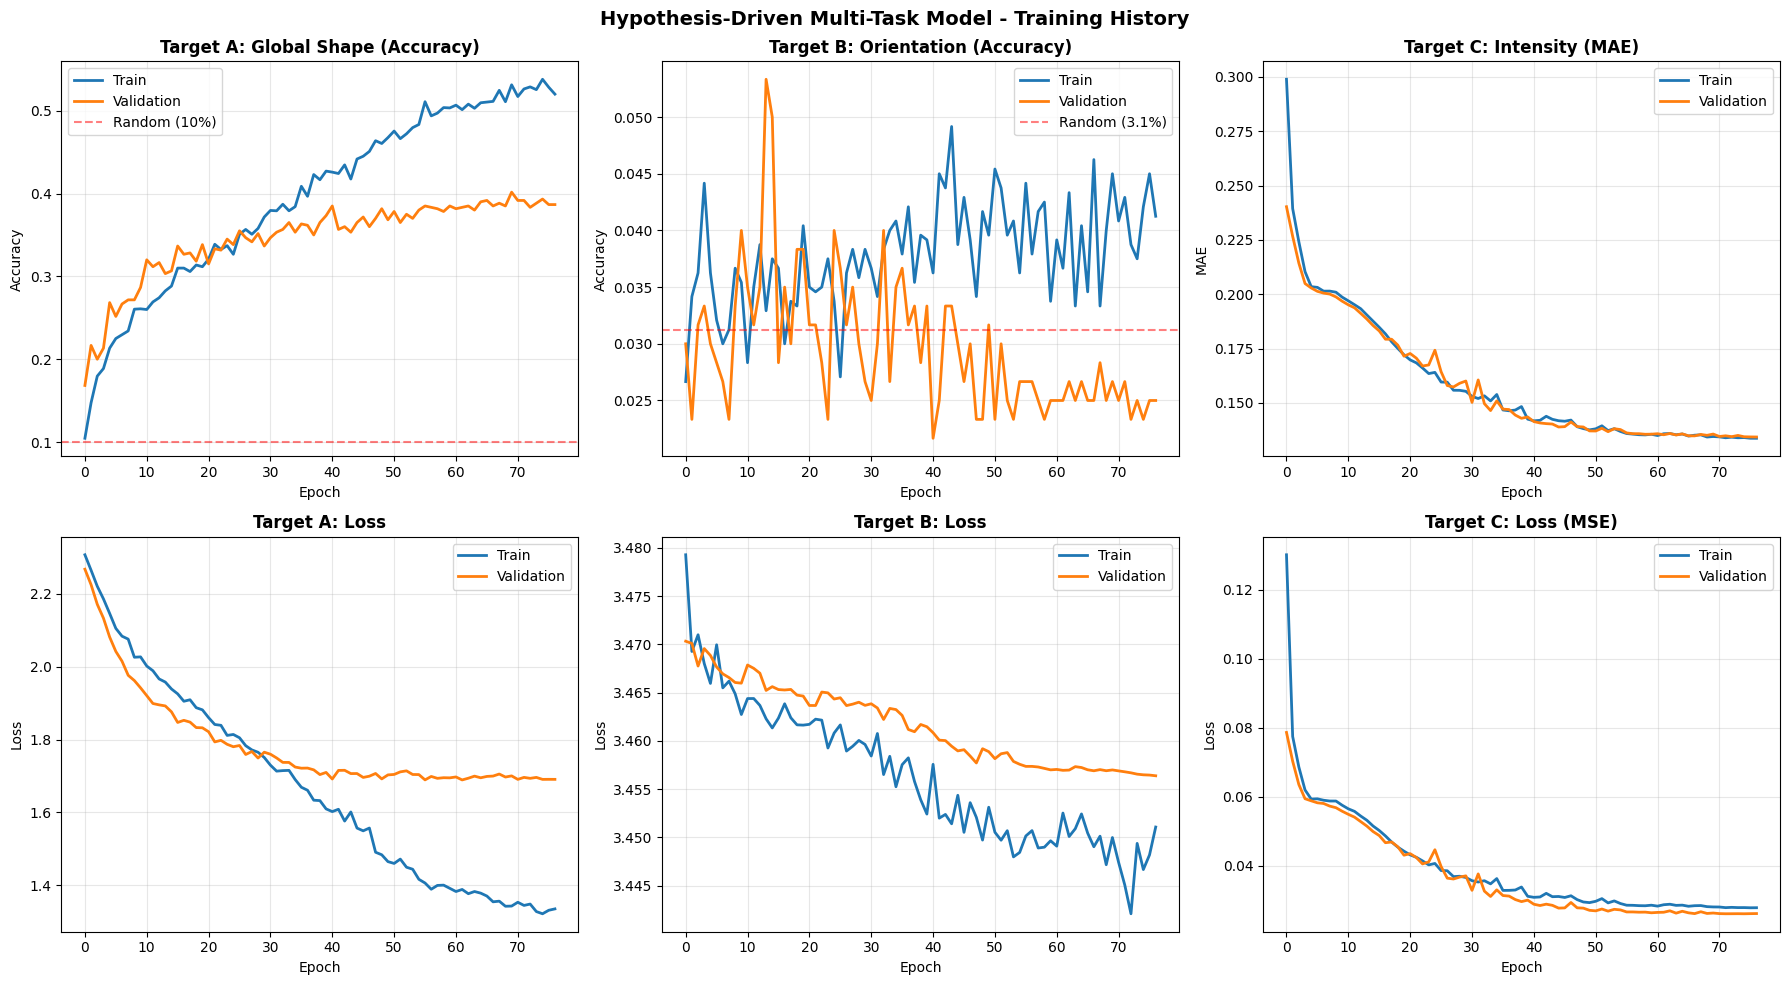


✓ Training completed in 77 epochs
  Best validation - Target A: 40.17%
  Best validation - Target B: 5.33%
  Best validation - Target C: 0.1343 MAE


In [8]:
# Plot training history for MTL model
def plot():
  fig, axes = plt.subplots(2, 3, figsize=(18, 10))
  fig.suptitle('Hypothesis-Driven Multi-Task Model - Training History', fontsize=14, fontweight='bold')

  # Target A - Accuracy
  axes[0, 0].plot(history_mtl.history['output_A_accuracy'], label='Train', linewidth=2)
  axes[0, 0].plot(history_mtl.history['val_output_A_accuracy'], label='Validation', linewidth=2)
  axes[0, 0].axhline(y=0.1, color='r', linestyle='--', alpha=0.5, label='Random (10%)')
  axes[0, 0].set_title('Target A: Global Shape (Accuracy)', fontweight='bold')
  axes[0, 0].set_xlabel('Epoch')
  axes[0, 0].set_ylabel('Accuracy')
  axes[0, 0].legend()
  axes[0, 0].grid(True, alpha=0.3)

  # Target A - Loss
  axes[1, 0].plot(history_mtl.history['output_A_loss'], label='Train', linewidth=2)
  axes[1, 0].plot(history_mtl.history['val_output_A_loss'], label='Validation', linewidth=2)
  axes[1, 0].set_title('Target A: Loss', fontweight='bold')
  axes[1, 0].set_xlabel('Epoch')
  axes[1, 0].set_ylabel('Loss')
  axes[1, 0].legend()
  axes[1, 0].grid(True, alpha=0.3)

  # Target B - Accuracy
  axes[0, 1].plot(history_mtl.history['output_B_accuracy'], label='Train', linewidth=2)
  axes[0, 1].plot(history_mtl.history['val_output_B_accuracy'], label='Validation', linewidth=2)
  axes[0, 1].axhline(y=1/32, color='r', linestyle='--', alpha=0.5, label='Random (3.1%)')
  axes[0, 1].set_title('Target B: Orientation (Accuracy)', fontweight='bold')
  axes[0, 1].set_xlabel('Epoch')
  axes[0, 1].set_ylabel('Accuracy')
  axes[0, 1].legend()
  axes[0, 1].grid(True, alpha=0.3)

  # Target B - Loss
  axes[1, 1].plot(history_mtl.history['output_B_loss'], label='Train', linewidth=2)
  axes[1, 1].plot(history_mtl.history['val_output_B_loss'], label='Validation', linewidth=2)
  axes[1, 1].set_title('Target B: Loss', fontweight='bold')
  axes[1, 1].set_xlabel('Epoch')
  axes[1, 1].set_ylabel('Loss')
  axes[1, 1].legend()
  axes[1, 1].grid(True, alpha=0.3)

  # Target C - MAE
  axes[0, 2].plot(history_mtl.history['output_C_mae'], label='Train', linewidth=2)
  axes[0, 2].plot(history_mtl.history['val_output_C_mae'], label='Validation', linewidth=2)
  axes[0, 2].set_title('Target C: Intensity (MAE)', fontweight='bold')
  axes[0, 2].set_xlabel('Epoch')
  axes[0, 2].set_ylabel('MAE')
  axes[0, 2].legend()
  axes[0, 2].grid(True, alpha=0.3)

  # Target C - Loss (MSE)
  axes[1, 2].plot(history_mtl.history['output_C_loss'], label='Train', linewidth=2)
  axes[1, 2].plot(history_mtl.history['val_output_C_loss'], label='Validation', linewidth=2)
  axes[1, 2].set_title('Target C: Loss (MSE)', fontweight='bold')
  axes[1, 2].set_xlabel('Epoch')
  axes[1, 2].set_ylabel('Loss')
  axes[1, 2].legend()
  axes[1, 2].grid(True, alpha=0.3)

  plt.tight_layout()
  plt.show()

  print(f"\n✓ Training completed in {len(history_mtl.history['loss'])} epochs")
  print(f"  Best validation - Target A: {max(history_mtl.history['val_output_A_accuracy'])*100:.2f}%")
  print(f"  Best validation - Target B: {max(history_mtl.history['val_output_B_accuracy'])*100:.2f}%")
  print(f"  Best validation - Target C: {min(history_mtl.history['val_output_C_mae']):.4f} MAE")

plot()